In [4]:
import pandas as pd

In [5]:
ngsl = pd.read_csv('../data/ngsl/NGSL_12_stats.csv')
print(ngsl.shape)
print(ngsl.head(10))
print(ngsl.columns.tolist())

(2809, 4)
  Lemma  SFI Rank    SFI  Adjusted Frequency per Million (U)
0   the         1  87.85                               60910
1    be         2  86.86                               48575
2   and         3  84.88                               30789
3    of         4  84.79                               30126
4    to         5  84.66                               29272
5     a         6  84.45                               27872
6    in         7  83.25                               21142
7  have         8  81.53                               14210
8    it         9  81.39                               13772
9   you        10  81.08                               12810
['Lemma', 'SFI Rank', 'SFI', 'Adjusted Frequency per Million (U)']


In [7]:
from datasets import load_dataset

cefr = load_dataset("UniversalCEFR/readme_en")
print(cefr)

DatasetDict({
    train: Dataset({
        features: ['title', 'lang', 'source_name', 'format', 'category', 'cefr_level', 'license', 'text'],
        num_rows: 2822
    })
})


In [8]:
df = cefr['train'].to_pandas()
print(df.shape)
print(df['cefr_level'].value_counts().sort_index())

(2822, 8)
cefr_level
A1    182
A2    673
B1    623
B2    896
C1    377
C2     71
Name: count, dtype: int64


In [10]:
print(df['format'].value_counts())
print()
print(df['source_name'].value_counts())

format
sentence-level    2822
Name: count, dtype: int64

source_name
readme    2822
Name: count, dtype: int64


In [11]:
  # Look at a few examples from each level                                                                                                   
  for level in ['A2', 'B1', 'B2', 'C1']:                                                                                                     
      print(f"\n--- {level} ---")                                                                                                            
      samples = df[df['cefr_level'] == level]['text'].head(3).tolist()                                                                       
      for s in samples:                                                                                                                      
          print(s)


--- A2 ---
The late 19th century marks the start of psychology as a scientific enterprise.
Cartridge paper is the basic type of drawing paper sold in pads.
This is called the observer effect.

--- B1 ---
If both firms select the same category,  both firms lose five million USD, since they have flooded the market with too much  cereal.
The market  mechanism is a useful and powerful analytical tool.
Both simple (r outine) and complex decision making begins with need r ecognition.

--- B2 ---
A cartel is a group of firms that have an explicit agreement to reduce output in order to  increase the price.
Balance theory  Fritz Heider's Balance Theory is a framework that can predict attitude and behavioural change.
Ad hoc wireless networks must also be conﬁgured with a routing protocol, so that paths may be found from one node to another.

--- C1 ---
The price elasticity of demand depends on the availability of substitutes.
To  find the derivative needed to calculate the price elasticities, t

In [14]:
cefr2 = load_dataset("UniversalCEFR/cefr_sp_en")                                                                                           
df2 = cefr2['train'].to_pandas()                                                                                                           
print(df2.shape)                                                                                                                           
print(df2['cefr_level'].value_counts().sort_index())  

README.md:   0%|          | 0.00/703 [00:00<?, ?B/s]

cefr-sp.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10004 [00:00<?, ? examples/s]

(10004, 8)
cefr_level
A1     124
A2    1271
B1    3305
B2    3330
C1    1744
C2     230
Name: count, dtype: int64


In [15]:
for level in ['A2', 'B1', 'B2', 'C1']:                                                                                                     
    print(f"\n--- {level} ---")                                                                                                            
    samples = df2[df2['cefr_level'] == level]['text'].head(3).tolist()                                                                     
    for s in samples:                                                                                                                      
        print(s) 


--- A2 ---
Ben must like his new car a lot .
Harrison got very excited when his parents gave him a car .
I like dogs more than cats .

--- B1 ---
He never trusts anyone except his older brother .
Do you have a wind chill calculator ?
Although you 've no doubt seen this kind of crime before , it is nevertheless shocking to see the violence .

--- B2 ---
She started to glue the pieces back to together , but then realized it was hopeless .
The season has changed and the warm spring air has given me hope .
The spectators sang to encourage their team .

--- C1 ---
This article explains why the use of embryonic cells is controversial .
The dermatologist diagnosed skin cancer .
The bleeding girl was helped to her feet by several bystanders and taken to the hospital .


In [16]:
df2['text_length'] = df2['text'].str.split().str.len()                                                                                     
print(df2.groupby('cefr_level')['text_length'].describe().round(1)) 

             count  mean  std  min   25%   50%   75%   max
cefr_level                                                
A1           124.0   8.5  3.2  5.0   6.0   7.0  11.0  18.0
A2          1271.0   9.0  3.1  5.0   7.0   8.0  10.0  26.0
B1          3305.0  13.0  4.8  5.0   9.0  12.0  16.0  30.0
B2          3330.0  16.9  5.6  5.0  13.0  16.0  21.0  33.0
C1          1744.0  18.2  6.0  5.0  14.0  18.0  23.0  34.0
C2           230.0  18.8  5.8  8.0  14.0  18.0  23.0  33.0


In [17]:
print(df2['category'].value_counts())                                                                                                      
print()                                                                                                                                    
print(df2['format'].value_counts())                                                                                                        
                                         

category
reference    10004
Name: count, dtype: int64

format
sentence-level    10004
Name: count, dtype: int64


In [19]:
import sys
sys.path.append('../src')

from classifier.features import load_ngsl, load_spacy, extract_features

ngsl = load_ngsl('../data/ngsl/NGSL_12_stats.csv')                                                                                         
nlp = load_spacy()
                                                                                                                                             
# Test on sentences from our dataset                                                                                                       
test_sentences = [                                                                                                                         
    ("A2", "I like dogs more than cats ."),                                                                                                
    ("B1", "Although you have no doubt seen this kind of crime before , it is nevertheless shocking ."),                                   
    ("B2", "The spectators sang to encourage their team ."),                                                                               
    ("C1", "The dermatologist diagnosed skin cancer ."),                                                                                   
]                                                                                                                                          
                                                                                                                                             
for level, sentence in test_sentences:                                                                                                     
    features = extract_features(sentence, nlp, ngsl)                                                                                       
    print(f"\n{level}: {sentence[:50]}")                                                                                                   
    for k, v in features.items():                                                                                                          
        print(f"  {k}: {v:.3f}")  




A2: I like dogs more than cats .
  avg_sent_len: 6.000
  ngsl_800: 0.667
  ngsl_1000: 0.833
  ngsl_2000: 1.000
  ngsl_3000: 1.000
  ttr: 1.000
  avg_tree_depth: 1.286
  subord_ratio: 0.000

B1: Although you have no doubt seen this kind of crime
  avg_sent_len: 15.000
  ngsl_800: 0.733
  ngsl_1000: 0.800
  ngsl_2000: 0.933
  ngsl_3000: 0.933
  ttr: 1.000
  avg_tree_depth: 2.000
  subord_ratio: 0.059

B2: The spectators sang to encourage their team .
  avg_sent_len: 7.000
  ngsl_800: 0.429
  ngsl_1000: 0.714
  ngsl_2000: 0.714
  ngsl_3000: 0.714
  ttr: 1.000
  avg_tree_depth: 1.500
  subord_ratio: 0.125

C1: The dermatologist diagnosed skin cancer .
  avg_sent_len: 5.000
  ngsl_800: 0.200
  ngsl_1000: 0.200
  ngsl_2000: 0.600
  ngsl_3000: 0.600
  ttr: 1.000
  avg_tree_depth: 1.167
  subord_ratio: 0.000


In [20]:
from datasets import load_dataset
                                                                                                                                             
# Load and filter dataset                                                                                                                  
cefr_data = load_dataset("UniversalCEFR/cefr_sp_en")                                                                                       
df_train = cefr_data['train'].to_pandas()                                                                                                  
df_train = df_train[df_train['cefr_level'].isin(['A2', 'B1', 'B2', 'C1'])].copy()                                                          
df_train = df_train.reset_index(drop=True)                                                                                                 
print(f"Training examples: {len(df_train)}") 

Training examples: 9650


In [21]:
from tqdm import tqdm
                                                                                                                                             
tqdm.pandas()                                                                                                                              
                                                                                                                                             
feature_rows = []                                                                                                                          
for text in tqdm(df_train['text'], desc="Extracting features"):
    features = extract_features(text, nlp, ngsl)                                                                                           
    feature_rows.append(features)                                                                                                          
                                                                                                                                             
df_features = pd.DataFrame(feature_rows)                                                                                                   
df_features['cefr_level'] = df_train['cefr_level'].values                                                                                  
                                                                                                                                             
print(df_features.shape)                                                                                                                   
print(df_features.head()) 

Extracting features: 100%|█████████████████████████████████████████████████████████████████████████████████| 9650/9650 [00:35<00:00, 269.07it/s]

(9650, 9)
   avg_sent_len  ngsl_800  ngsl_1000  ngsl_2000  ngsl_3000    ttr  \
0           8.0  0.750000   0.750000   0.750000   0.750000  1.000   
1          11.0  0.727273   0.727273   0.727273   0.727273  1.000   
2           6.0  0.666667   0.833333   1.000000   1.000000  1.000   
3           8.0  0.875000   0.875000   0.875000   0.875000  0.875   
4           6.0  0.333333   0.333333   0.333333   0.500000  1.000   

   avg_tree_depth  subord_ratio cefr_level  
0        1.222222      0.000000         A2  
1        1.666667      0.083333         A2  
2        1.285714      0.000000         A2  
3        1.000000      0.000000         A2  
4        1.571429      0.000000         A2  


In [22]:
print(df_features.isnull().sum())

avg_sent_len      0
ngsl_800          0
ngsl_1000         0
ngsl_2000         0
ngsl_3000         0
ttr               0
avg_tree_depth    0
subord_ratio      0
cefr_level        0
dtype: int64


In [26]:
from sklearn.model_selection import train_test_split                                                                                       
from sklearn.naive_bayes import GaussianNB                                                                                                 
from sklearn.linear_model import LogisticRegression                                                                                        
from sklearn.preprocessing import StandardScaler                                                                                           
from sklearn.metrics import classification_report                                                                                          
                                                                                                                                             
# Separate features (X) from labels (y)                                                                                                    
feature_cols = ['avg_sent_len', 'ngsl_800', 'ngsl_1000', 'ngsl_2000', 'ngsl_3000',                                                         
                'ttr', 'avg_tree_depth', 'subord_ratio']                                                                                   
                                                                                                                                             
X = df_features[feature_cols].to_numpy(dtype=float)                                                                                                       
y = df_features['cefr_level'].to_numpy()                                                                                                       
                                                                                                                                             
# 80% train, 20% test — random_state makes it reproducible                                                                                 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)                                      
                                                                                                                                             
print(f"Train: {X_train.shape}, Test: {X_test.shape}")                                                                                     
                                                                                                                                             
# --- Naive Bayes ---                                                                                                                      
nb = GaussianNB()
nb.fit(X_train, y_train)                                                                                                                   
print("\n=== Naive Bayes ===")                                                                                                             
print(classification_report(y_test, nb.predict(X_test)))                                                                                   
                                                                                                                                             
# --- Logistic Regression ---                                                                                                              
# Scale features first — LR is sensitive to feature magnitude                                                                              
scaler = StandardScaler()                                                                                                                  
X_train_scaled = scaler.fit_transform(X_train)                                                                                             
X_test_scaled = scaler.transform(X_test)                                                                                                   
                                                                                                                                             
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)                                                           
lr.fit(X_train_scaled, y_train)                                                                                                            
print("\n=== Logistic Regression ===")                                                                                                     
print(classification_report(y_test, lr.predict(X_test_scaled)))  

Train: (7720, 8), Test: (1930, 8)

=== Naive Bayes ===
              precision    recall  f1-score   support

          A2       0.42      0.57      0.49       254
          B1       0.52      0.45      0.48       661
          B2       0.50      0.46      0.48       666
          C1       0.38      0.43      0.40       349

    accuracy                           0.47      1930
   macro avg       0.46      0.48      0.46      1930
weighted avg       0.47      0.47      0.47      1930


=== Logistic Regression ===
              precision    recall  f1-score   support

          A2       0.39      0.70      0.50       254
          B1       0.52      0.42      0.46       661
          B2       0.53      0.33      0.40       666
          C1       0.40      0.60      0.48       349

    accuracy                           0.46      1930
   macro avg       0.46      0.51      0.46      1930
weighted avg       0.48      0.46      0.45      1930



Matplotlib is building the font cache; this may take a moment.


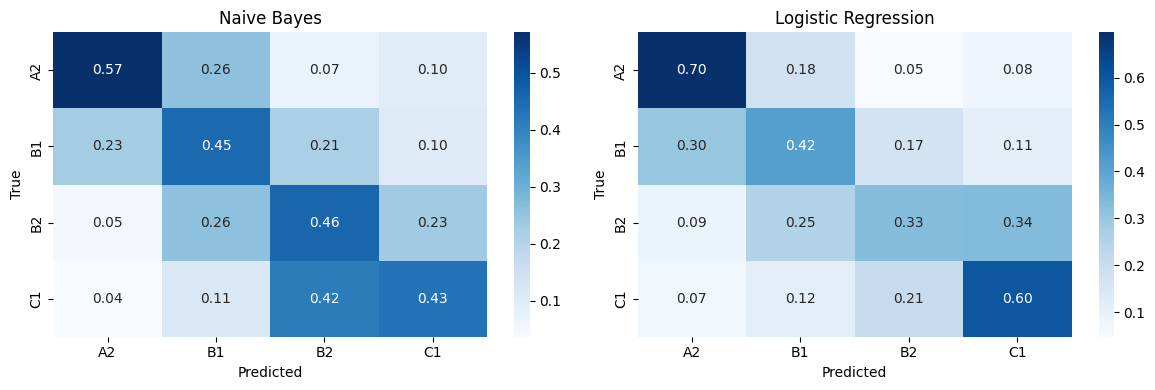

In [27]:
import matplotlib.pyplot as plt                                                                                                            
import seaborn as sns                                                                                                                      
from sklearn.metrics import confusion_matrix                                                                                               
import numpy as np                                                                                                                         
                                                                                                                                             
labels = ['A2', 'B1', 'B2', 'C1']                                                                                                          
                  
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                                                                                            
                  
for ax, model, preds, title in [                                                                                                           
    (axes[0], nb, nb.predict(X_test), "Naive Bayes"),
    (axes[1], lr, lr.predict(X_test_scaled), "Logistic Regression"),                                                                       
]:                                                                                                                                         
    cm = confusion_matrix(y_test, preds, labels=labels)                                                                                    
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)                                                                              
    sns.heatmap(cm_pct, annot=True, fmt='.2f', xticklabels=labels,                                                                         
                  yticklabels=labels, ax=ax, cmap='Blues')                                                                                   
    ax.set_xlabel('Predicted')                                                                                                             
    ax.set_ylabel('True')                                                                                                                  
    ax.set_title(title)                                                                                                                    
                                                                                                                                             
plt.tight_layout()                                                                                                                         
plt.show()   

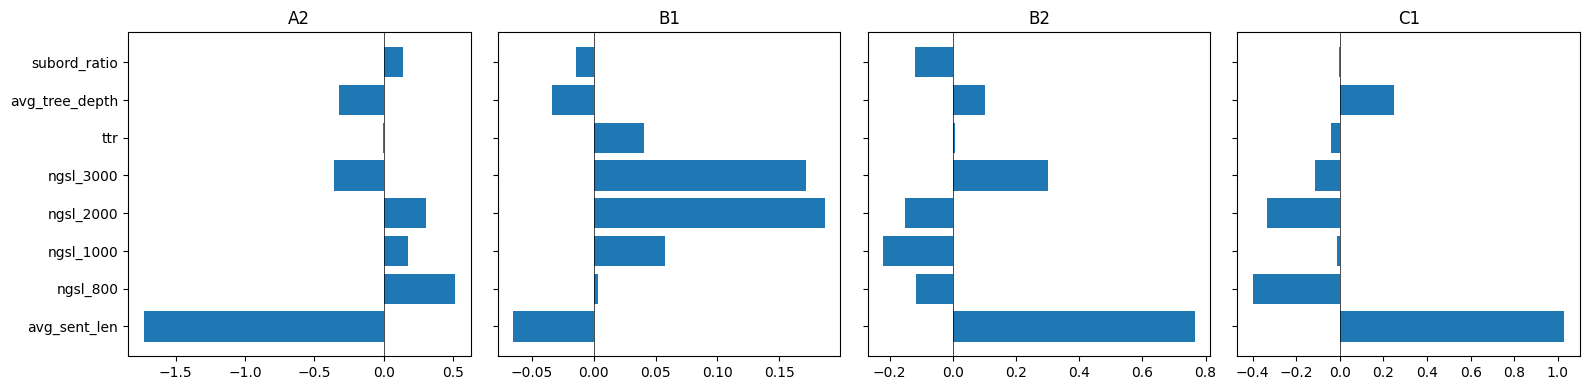

In [28]:
feature_names = feature_cols
coefs = lr.coef_  # shape: (4 classes, 8 features)                                                                                         
                                                                                                                                             
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)                                                                               
for i, (ax, label) in enumerate(zip(axes, lr.classes_)):                                                                                   
    ax.barh(feature_names, coefs[i])                                                                                                       
    ax.axvline(0, color='black', linewidth=0.5)                                                                                            
    ax.set_title(label)                                                                                                                    
plt.tight_layout()                                                                                                                         
plt.show() 

In [29]:
# Reload the updated features module                                                                                                       
import importlib                                                                                                                           
import sys                                                                                                                                 
                                                                                                                                             
# Remove cached module so Python reloads from disk                                                                                         
if 'classifier.features' in sys.modules:                                                                                                   
    del sys.modules['classifier.features']                                                                                                 
                                                                                                                                             
from classifier.features import load_ngsl, load_spacy, extract_features                                                                    
                                                                                                                                             
# Re-extract with new features (ngsl and nlp already loaded)                                                                               
feature_rows2 = []                                                                                                                       
for text in tqdm(df_train['text'], desc="Extracting features"):                                                                            
    features = extract_features(text, nlp, ngsl)                                                                                           
    feature_rows2.append(features)                                                                                                         
                                                                                                                                             
df_features2 = pd.DataFrame(feature_rows2)                                                                                                 
df_features2['cefr_level'] = df_train['cefr_level'].values                                                                                 
print(df_features2.columns.tolist()) 

Extracting features: 100%|█████████████████████████████████████████████████████████████████████████████████| 9650/9650 [00:40<00:00, 235.61it/s]

['avg_sent_len', 'ngsl_800', 'ngsl_1000', 'ngsl_2000', 'ngsl_3000', 'ttr', 'avg_tree_depth', 'subord_ratio', 'avg_word_len', 'out_of_ngsl', 'cefr_level']


In [30]:
feature_cols2 = ['avg_sent_len', 'ngsl_800', 'ngsl_1000', 'ngsl_2000', 'ngsl_3000',
                   'ttr', 'avg_tree_depth', 'subord_ratio', 'avg_word_len', 'out_of_ngsl']                                                   
                                                                                                                                             
X2 = df_features2[feature_cols2].to_numpy(dtype=float)                                                                                     
y2 = df_features2['cefr_level'].to_numpy()                                                                                                 
                                                                                                                                             
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)                               
                                                                                                                                             
# Naive Bayes                                                                                                                              
nb2 = GaussianNB()
nb2.fit(X2_train, y2_train)                                                                                                                
print("=== Naive Bayes (10 features) ===")                                                                                                 
print(classification_report(y2_test, nb2.predict(X2_test)))                                                                                
                                                                                                                                             
# Logistic Regression                                                                                                                      
scaler2 = StandardScaler()                                                                                                                 
X2_train_scaled = scaler2.fit_transform(X2_train)                                                                                          
X2_test_scaled = scaler2.transform(X2_test)                                                                                                
                                                                                                                                             
lr2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)                                                          
lr2.fit(X2_train_scaled, y2_train)                                                                                                         
print("=== Logistic Regression (10 features) ===")                                                                                         
print(classification_report(y2_test, lr2.predict(X2_test_scaled)))     

=== Naive Bayes (10 features) ===
              precision    recall  f1-score   support

          A2       0.49      0.54      0.52       254
          B1       0.53      0.48      0.50       661
          B2       0.50      0.46      0.48       666
          C1       0.39      0.50      0.44       349

    accuracy                           0.48      1930
   macro avg       0.48      0.49      0.48      1930
weighted avg       0.49      0.48      0.49      1930

=== Logistic Regression (10 features) ===
              precision    recall  f1-score   support

          A2       0.45      0.70      0.55       254
          B1       0.54      0.45      0.49       661
          B2       0.53      0.38      0.44       666
          C1       0.45      0.66      0.54       349

    accuracy                           0.49      1930
   macro avg       0.49      0.55      0.50      1930
weighted avg       0.51      0.49      0.49      1930



In [31]:
import joblib                                                                                                                              
import os                                                                                                                                  
   
os.makedirs('../src/classifier/models', exist_ok=True)                                                                                     
                  
joblib.dump(lr2,     '../src/classifier/models/lr_classifier.joblib')                                                                      
joblib.dump(scaler2, '../src/classifier/models/lr_scaler.joblib')
joblib.dump(ngsl,    '../src/classifier/models/ngsl_sets.joblib')                                                                          
                                                                                                                                             
print("Saved: lr_classifier.joblib, lr_scaler.joblib, ngsl_sets.joblib")   

Saved: lr_classifier.joblib, lr_scaler.joblib, ngsl_sets.joblib


In [32]:
import importlib, sys
for mod in list(sys.modules.keys()):                                                                                                       
    if 'classifier' in mod:                                                                                                                
        del sys.modules[mod]                                                                                                               
                                                                                                                                             
from classifier.classify import load_classifier, classify                                                                                  
                                                                                                                                             
clf = load_classifier()                                                                                                                    
                                                                                                                                           
test_texts = [                                                                                                                             
      ("A2 target", "I like dogs more than cats. She went to the shop. He is happy today."),                                               
      ("B2 target", "The spectators sang loudly to encourage their struggling team throughout the match."),                                  
      ("Generated story excerpt", "Mr. Hale locked the door and checked the window. He did not trust anyone in the building."),              
]                                                                                                                                          
                                                                                                                                             
for label, text in test_texts:                                                                                                             
    result = classify(text, clf)                                                                                                         
    print(f"{label}: predicted={result['level']} confidence={result['confidence']:.2f}")                                                   
    print(f"  probs: {result['probs']}")

A2 target: predicted=A2 confidence=0.92
  probs: {'A2': 0.9151646468618287, 'B1': 0.08265697083542782, 'B2': 0.002123963739667631, 'C1': 5.441856307603906e-05}
B2 target: predicted=C1 confidence=0.46
  probs: {'A2': 0.008866043401231706, 'B1': 0.20303670445960212, 'B2': 0.3246770560455577, 'C1': 0.4634201960936086}
Generated story excerpt: predicted=A2 confidence=0.55
  probs: {'A2': 0.5498068581333335, 'B1': 0.3579731172509591, 'B2': 0.08004806185716175, 'C1': 0.012171962758545561}
